In [5]:
!pip install xgboost
!pip install imbalanced-learn
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.4 MB/s eta 0:00:00


In [11]:

# =========================
# File: notebooks/modeling.ipynb
# Task: Chạy 4 experiment, tạo model_results.csv, lưu best_model.pkl
# =========================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import joblib
import os

# -----------------------
# 1. Tạo thư mục lưu trữ
# -----------------------
os.makedirs("reports", exist_ok=True)
os.makedirs("models", exist_ok=True)

# -----------------------
# 2. Đọc dữ liệu đã clean
# -----------------------
dataset = pd.read_csv("cleaned_data.csv")

# Tách X và y
X = dataset.drop(["CustomerID", "Churn"], axis=1, errors="ignore")
y = dataset["Churn"]

# Chia train/test (20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------
# 3. Định nghĩa các experiment
# -----------------------
experiments = []

# EXP01: No Upsampling, No Scale, XGBoost
exp1_model = xgb.XGBClassifier(random_state=42, n_estimators=200, eval_metric="logloss")
exp1_model.fit(X_train, y_train)
y_pred = exp1_model.predict(X_test)
y_proba = exp1_model.predict_proba(X_test)[:, 1]

experiments.append({
    "Model": "XGBoost",
    "Upsampling": "No",
    "Scale": "No",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "AUC": roc_auc_score(y_test, y_proba),
    "Model_obj": exp1_model
})

# EXP02: No Upsampling, Scale, Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

exp2_model = LogisticRegression(random_state=42, max_iter=1000)
exp2_model.fit(X_train_scaled, y_train)
y_pred = exp2_model.predict(X_test_scaled)
y_proba = exp2_model.predict_proba(X_test_scaled)[:, 1]

experiments.append({
    "Model": "Logistic Regression",
    "Upsampling": "No",
    "Scale": "Yes",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "AUC": roc_auc_score(y_test, y_proba),
    "Model_obj": exp2_model
})

# EXP03: Upsampling SMOTE, No Scale, Gradient Boosting
sm = SMOTE(k_neighbors=5, random_state=42)
X_train_resample, y_train_resample = sm.fit_resample(X_train, y_train)

exp3_model = GradientBoostingClassifier(random_state=42)
exp3_model.fit(X_train_resample, y_train_resample)
y_pred = exp3_model.predict(X_test)
y_proba = exp3_model.predict_proba(X_test)[:, 1]

experiments.append({
    "Model": "Gradient Boosting",
    "Upsampling": "Yes",
    "Scale": "No",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "AUC": roc_auc_score(y_test, y_proba),
    "Model_obj": exp3_model
})

# EXP04: Upsampling SMOTE, Scale, Random Forest
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_resample, y_train_resample = sm.fit_resample(X_train_scaled, y_train)

exp4_model = RandomForestClassifier(random_state=42, n_estimators=200)
exp4_model.fit(X_train_resample, y_train_resample)
y_pred = exp4_model.predict(X_test_scaled)
y_proba = exp4_model.predict_proba(X_test_scaled)[:, 1]

experiments.append({
    "Model": "Random Forest",
    "Upsampling": "Yes",
    "Scale": "Yes",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "AUC": roc_auc_score(y_test, y_proba),
    "Model_obj": exp4_model
})


Top 10 features ảnh hưởng đến Churn:
                               feature  importance
0                               Tenure    0.151624
1                             Complain    0.088403
2  PreferedOrderCat_Laptop & Accessory    0.062143
3                 MaritalStatus_Single    0.051864
4                      NumberOfAddress    0.042051
5             PreferedOrderCat_Grocery    0.040981
6                             CityTier    0.040276
7        PreferredPaymentMode_E wallet    0.035353
8             NumberOfDeviceRegistered    0.035127
9             PreferredPaymentMode_UPI    0.033851


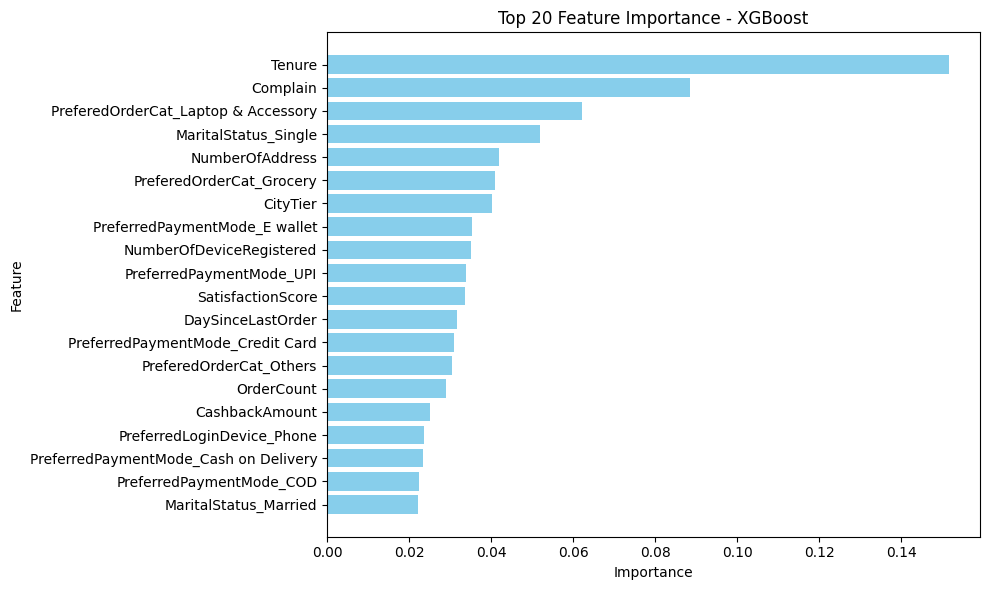

In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Tạo thư mục reports nếu chưa tồn tại
os.makedirs("reports", exist_ok=True)

# Kiểm tra model có attribute feature_importances_ hay không
if hasattr(best_exp["Model_obj"], "feature_importances_"):
    feature_names = X.columns
    importances = best_exp["Model_obj"].feature_importances_

    # Tạo DataFrame sắp xếp theo importance
    feat_imp = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    feat_imp = feat_imp.sort_values(by="importance", ascending=False).reset_index(drop=True)

    # In bảng top 10 feature ra console
    print("Top 10 features ảnh hưởng đến Churn:")
    print(feat_imp.head(10))

    # Vẽ top 20 features
    plt.figure(figsize=(10,6))
    plt.barh(feat_imp['feature'][:20][::-1], feat_imp['importance'][:20][::-1], color='skyblue')
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"Top 20 Feature Importance - {best_exp['Model']}")
    plt.tight_layout()
    plt.savefig("reports/feature_importance.png", dpi=300)
    plt.show()
else:
    print(f"Model {best_exp['Model']} không có attribute feature_importances_, không thể vẽ feature importance.")

In [10]:
# -----------------------
# 4. Tạo DataFrame CSV
# -----------------------
results_df = pd.DataFrame([{
    "Model": e["Model"],
    "Upsampling": e["Upsampling"],
    "Scale": e["Scale"],
    "Accuracy": e["Accuracy"],
    "F1": e["F1"],
    "Recall": e["Recall"],
    "AUC": e["AUC"]
} for e in experiments])

# Lưu CSV
results_df.to_csv("reports/model_results.csv", index=False)
print("Saved CSV: reports/model_results.csv")

# -----------------------
# 5. In kết quả và nhận xét
# -----------------------
print("\n=== Model Results ===")
print(results_df)

# Tìm model tốt nhất theo F1-score
best_exp = max(experiments, key=lambda x: x["F1"])
print("\nBest model based on F1-score:", best_exp["Model"])
print("Accuracy: {:.3f}, F1: {:.3f}, Recall: {:.3f}, AUC: {:.3f}".format(
    best_exp["Accuracy"], best_exp["F1"], best_exp["Recall"], best_exp["AUC"]
))

# Nhận xét: so sánh các chỉ số
print("\n=== Model Comparison ===")
for e in experiments:
    print(f"{e['Model']}: Accuracy={e['Accuracy']:.3f}, F1={e['F1']:.3f}, Recall={e['Recall']:.3f}, AUC={e['AUC']:.3f}")

# -----------------------
# 6. Lưu model tốt nhất
# -----------------------
joblib.dump(best_exp["Model_obj"], "models/best_model.pkl")
print("Saved best model to: models/best_model.pkl")

Saved CSV: reports/model_results.csv

=== Model Results ===
                 Model Upsampling Scale  Accuracy        F1    Recall  \
0              XGBoost         No    No  0.963374  0.889632  0.875000   
1  Logistic Regression         No   Yes  0.902331  0.648000  0.532895   
2    Gradient Boosting        Yes    No  0.892342  0.690096  0.710526   
3        Random Forest        Yes   Yes  0.940067  0.818792  0.802632   

        AUC  
0  0.983302  
1  0.898075  
2  0.917566  
3  0.977650  

Best model based on F1-score: XGBoost
Accuracy: 0.963, F1: 0.890, Recall: 0.875, AUC: 0.983

=== Model Comparison ===
XGBoost: Accuracy=0.963, F1=0.890, Recall=0.875, AUC=0.983
Logistic Regression: Accuracy=0.902, F1=0.648, Recall=0.533, AUC=0.898
Gradient Boosting: Accuracy=0.892, F1=0.690, Recall=0.711, AUC=0.918
Random Forest: Accuracy=0.940, F1=0.819, Recall=0.803, AUC=0.978
Saved best model to: models/best_model.pkl


In [8]:
data_1 = pd.read_pickle("models/best_model.pkl")
print(data_1)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)
